In [15]:
import numpy as np

In [1]:
import pandas as pd

In [3]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt

In [4]:
from moddata import load_data

## 1. Load the data

In [5]:
data = load_data("spx_1901-2025")
data = data["2000-01-01":]

In [6]:
data.head()

,open,high,low,close,volume
date,,,,,
2000-01-03,1469.25,1478.00,1438.36,1455.22,517666667.0
2000-01-04,1455.22,1455.22,1397.43,1399.42,560555556.0
2000-01-05,1399.42,1413.27,1377.68,1402.11,603055556.0
2000-01-06,1402.11,1411.90,1392.10,1403.45,606833333.0
2000-01-07,1403.45,1441.47,1400.73,1441.47,680666667.0


<Axes: title={'center': 'SP500 Close Prices Since Jan 1st, 2000'}, xlabel='date'>

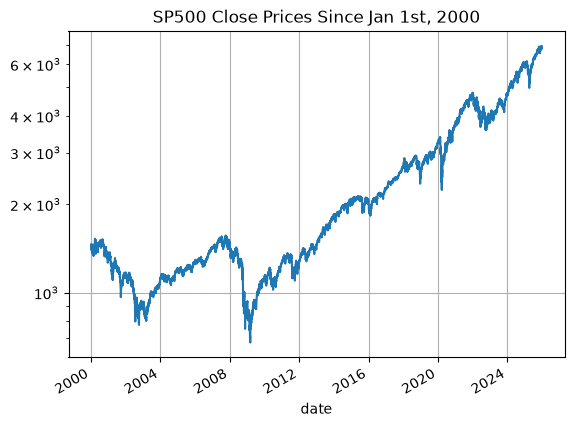

In [11]:
data["close"].plot(grid=True, title="SP500 Close Prices Since Jan 1st, 2000", logy=True)

## 2. Add some features

In [13]:
data["year"] = data.index.year

In [16]:
data["log_ret"] = np.log(data["close"] / data["open"])

In [25]:
data["close_ewma200"] = data["close"].ewm(halflife=200, adjust=False).mean()
data["close_ewma50"] = data["close"].ewm(halflife=50, adjust=False).mean()

In [18]:
data["bin_ret"] = np.where(data["log_ret"] >= 0, 1, -1)

In [24]:
pd.crosstab(index=data["year"], columns=data["bin_ret"], margins=True, normalize="index")

bin_ret,-1,1
year,,
2000,0.523810,0.476190
2001,0.520161,0.479839
2002,0.555556,0.444444
2003,0.456349,0.543651
2004,0.448413,0.551587
2005,0.440476,0.559524
2006,0.438247,0.561753
2007,0.462151,0.537849
2008,0.501976,0.498024


## 3. Look at Moving Averages

In [26]:
ma_data = data["2019-01-01":]

In [27]:
ma_data.head()

,open,high,low,close,volume,year,log_ret,bin_ret,close_ewma200,close_ewma50
date,,,,,,,,,,
2019-01-02,2476.96,2519.49,2467.47,2510.03,2.073978e+09,2019,0.013263,1,2556.067959,2717.618114
2019-01-03,2491.92,2493.14,2443.96,2447.89,2.123811e+09,2019,-0.017827,-1,2555.693692,2713.904687
2019-01-04,2474.33,2538.07,2474.33,2531.94,2.340783e+09,2019,0.023016,1,2555.611511,2711.399526
2019-01-07,2535.61,2566.16,2524.56,2549.69,2.280394e+09,2019,0.005538,1,2555.591024,2709.173223
2019-01-08,2568.11,2579.82,2547.56,2574.41,2.268350e+09,2019,0.002450,1,2555.656132,2707.317898


<Axes: xlabel='date'>

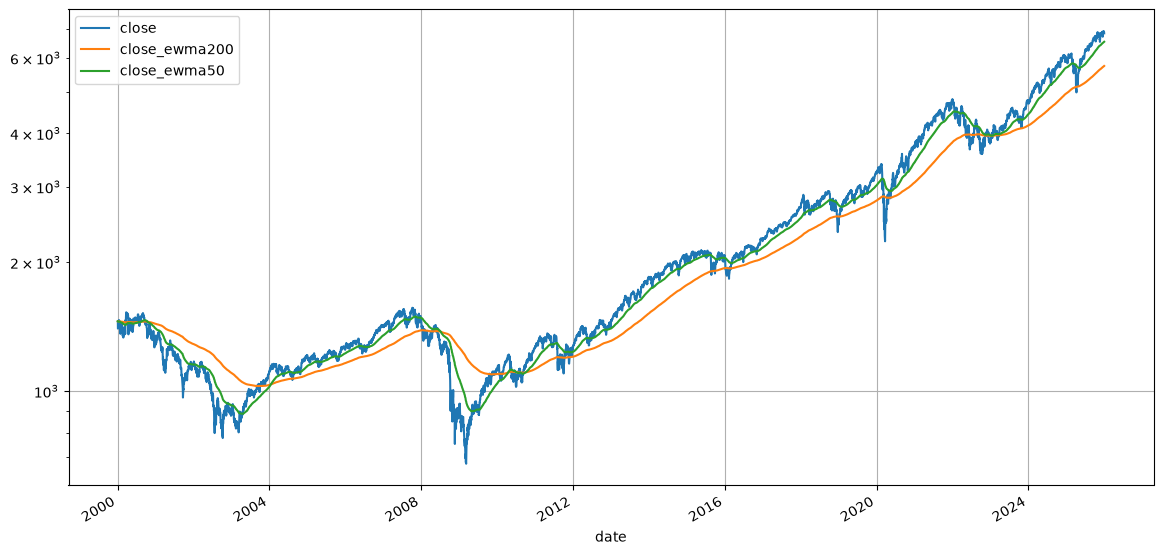

In [31]:
data[["close", "close_ewma200", "close_ewma50"]].plot(grid=True, logy=True, figsize=(14, 7))

## 4. Look at Distribution of Log-Returns Since 2019

In [32]:
data = data["2019-01-01":]

<Axes: >

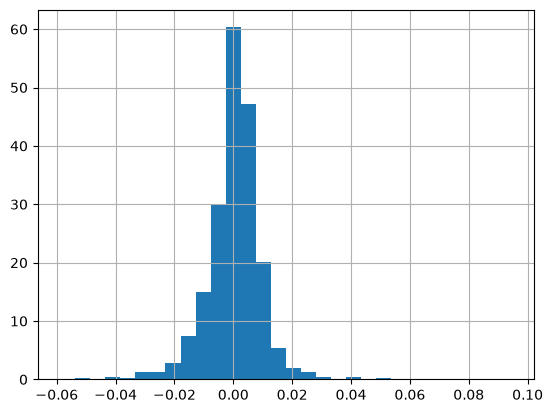

In [38]:
data["log_ret"].hist(grid=True, bins=30, density=True)

In [33]:
data.head()

,open,high,low,close,volume,year,log_ret,bin_ret,close_ewma200,close_ewma50
date,,,,,,,,,,
2019-01-02,2476.96,2519.49,2467.47,2510.03,2.073978e+09,2019,0.013263,1,2556.067959,2717.618114
2019-01-03,2491.92,2493.14,2443.96,2447.89,2.123811e+09,2019,-0.017827,-1,2555.693692,2713.904687
2019-01-04,2474.33,2538.07,2474.33,2531.94,2.340783e+09,2019,0.023016,1,2555.611511,2711.399526
2019-01-07,2535.61,2566.16,2524.56,2549.69,2.280394e+09,2019,0.005538,1,2555.591024,2709.173223
2019-01-08,2568.11,2579.82,2547.56,2574.41,2.268350e+09,2019,0.002450,1,2555.656132,2707.317898


In [42]:
data["log_ret_decile"] = pd.qcut(data["log_ret"], q=10, labels=False)

In [44]:
pd.crosstab(
    columns=data["log_ret_decile"],
    index=data["year"],
    normalize="columns"
)

log_ret_decile,0,1,2,3,4,5,6,7,8,9
year,,,,,,,,,,
2019,0.051136,0.119318,0.113636,0.215909,0.181818,0.221591,0.227273,0.119318,0.113636,0.068182
2020,0.227273,0.147727,0.096591,0.090909,0.113636,0.096591,0.153409,0.153409,0.153409,0.204545
2021,0.096591,0.130682,0.181818,0.130682,0.187500,0.159091,0.113636,0.164773,0.142045,0.125000
2022,0.318182,0.170455,0.119318,0.102273,0.062500,0.045455,0.079545,0.068182,0.142045,0.318182
2023,0.107955,0.164773,0.130682,0.130682,0.136364,0.176136,0.153409,0.136364,0.136364,0.147727
2024,0.079545,0.119318,0.170455,0.221591,0.147727,0.181818,0.159091,0.164773,0.142045,0.045455
2025,0.119318,0.147727,0.187500,0.107955,0.170455,0.119318,0.113636,0.193182,0.170455,0.090909
